# Final report

**Dang Dung Ho**, AI360

Lensless image reconstruction on the DigiCam dataset.

- Code: [github.com/tolyaho/lensless-computational-imaging](https://github.com/tolyaho/lensless-computational-imaging)
- Checkpoints: [tolyho/lensless-computational-imaging-checkpoints](https://huggingface.co/tolyho/lensless-computational-imaging-checkpoints)
- Demo: `notebooks/demo.ipynb`

## 1. Setup

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = ROOT / "reports" / "tables"

## 2. Final test metrics

Dataset: DigiCam **test** split, `n = 1500`. ROI: `[80:280, 100:366]`, `use_roi = true`.

In [2]:
metrics = pd.read_csv(TABLES / "final_metrics.csv")
display(
    metrics[
        ["rank", "method", "psnr", "ssim", "mse", "lpips", "params", "split"]
    ]
)

,rank,method,psnr,ssim,mse,lpips,params,split
0,1,LeADMM-5 + DRUNet pre+post,17.3128,0.4446,0.0232,0.5766,8512016,test
1,2,LeADMM-5 + DRUNet post,16.6853,0.4224,0.0263,0.5965,8337293,test
2,3,FlatNet-lite,16.1210,0.3801,0.0293,0.6056,2725132,test
3,4,LeADMM-5 + DRUNet pre,15.2942,0.3104,0.0348,0.6859,8337293,test
4,5,ADMM-100 + bg sub,10.5661,0.2411,0.1133,0.8203,0,test
5,6,LeADMM-20,8.1522,0.2378,0.1600,0.7659,40,test


## 3. Experiment descriptions and results

| Method | Pipeline | Test PSNR (dB) | Note |
| --- | --- | ---: | --- |
| ADMM-100 + bg sub | lensless + PSF → ADMM-100 → bg sub | 10.57 | fixed baseline |
| LeADMM-20 | lensless + PSF → unrolled ADMM-20 | 8.15 | 40 learned scalars |
| LeADMM-5 + DRUNet pre | lensless → DRUNet → LeADMM-5 | 15.29 | pre only |
| LeADMM-5 + DRUNet post | lensless → LeADMM-5 → DRUNet | 16.69 | post only |
| **LeADMM-5 + DRUNet pre+post** | lensless → DRUNet → LeADMM-5 → DRUNet | **17.31** | **best** |
| FlatNet-lite (bonus, non-ADMM) | lensless + PSF → Wiener → DRUNet | 16.12 | fast baseline |

### ADMM-100 + bg sub

Setup: fixed ADMM, 100 iterations, 10 CG steps, fixed `mu=1e-4`, `tau=2e-4`, background subtraction.

Result: PSNR 10.57, SSIM 0.241, MSE 0.113, LPIPS 0.820.

Takeaway: useful physics baseline, but slow and visually weak.

### LeADMM-20

Setup: 20 unrolled ADMM layers, trainable `mu_i` / `tau_i`, 40 trainable scalars.

Result: PSNR 8.15, SSIM 0.238, MSE 0.160, LPIPS 0.766.

Takeaway: learning only ADMM parameters is not enough.

### LeADMM-5 + DRUNet pre

Setup: `lensless -> DRUNet_pre -> LeADMM-5`.

Result: PSNR 15.29, SSIM 0.310, MSE 0.035, LPIPS 0.686.

Takeaway: learned preprocessing helps, but no final cleanup.

### LeADMM-5 + DRUNet post

Setup: `lensless -> LeADMM-5 -> DRUNet_post`.

Result: PSNR 16.69, SSIM 0.422, MSE 0.026, LPIPS 0.597.

Takeaway: strongest single CNN module.

### LeADMM-5 + DRUNet pre+post

Setup: `lensless -> DRUNet_pre -> LeADMM-5 -> DRUNet_post`.

Result: PSNR 17.31, SSIM 0.445, MSE 0.023, LPIPS 0.577.

Takeaway: best final model.

### FlatNet-lite (bonus, non-ADMM)

Setup: `lensless + PSF -> learned Wiener inversion -> DRUNet`.

Result: PSNR 16.12, SSIM 0.380, MSE 0.029, LPIPS 0.606.

Takeaway: strong non-ADMM bonus baseline — much faster, less physically constrained.

## 4. Difference, benefits, drawbacks

| Method | Difference from previous | Benefits | Drawbacks |
| --- | --- | --- | --- |
| ADMM-100 + bg sub | fixed optimization baseline | no training; interpretable | slow; low ROI quality |
| LeADMM-20 | learned μᵢ, τᵢ per iteration | still physics-based | only 40 params; weak quality |
| LeADMM-5 + DRUNet pre | DRUNet before LeADMM-5 | cleaner input to solver | no output cleanup |
| LeADMM-5 + DRUNet post | DRUNet after LeADMM-5 | strongest single module | raw measurement into ADMM |
| LeADMM-5 + DRUNet pre+post | DRUNet before and after | best quality | larger model; ADMM cost |
| FlatNet-lite | no ADMM loop | fastest; competitive | less physics-strict |

## 5. Quantitative comparison

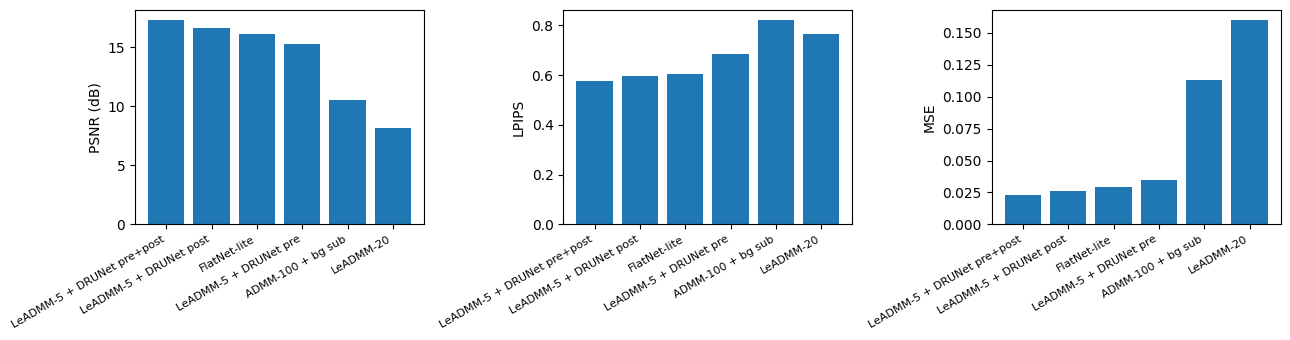

In [3]:
test = metrics[metrics["split"] == "test"].sort_values("psnr", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, ylab in zip(
    axes,
    ["psnr", "lpips", "mse"],
    ["PSNR (dB)", "LPIPS", "MSE"],
):
    ax.bar(test["method"], test[col])
    ax.set_ylabel(ylab)
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right", fontsize=8)

fig.tight_layout()
display(fig)
plt.close(fig)

## 6. Qualitative comparison

Grids from `scripts/make_qualitative_grid.py`.

![Qualitative comparison](../reports/assets/qualitative/final_comparison_grid.png)

![Compact comparison](../reports/assets/qualitative/final_comparison_grid_compact.png)

## 7. Reconstruction speed

Script: `python measure_speed.py --num-images 50 --warmup 5 --device cuda --output-path reports/tables/speed.json`

,method,seconds_per_image,images_per_second,num_images,device
0,ADMM-100 + bg sub,1.050103,0.952288,50,cuda
1,LeADMM-20,0.209290,4.778048,50,cuda
2,LeADMM-5 + DRUNet pre,0.062636,15.965308,50,cuda
3,LeADMM-5 + DRUNet post,0.062845,15.912274,50,cuda
4,LeADMM-5 + DRUNet pre+post,0.065334,15.305991,50,cuda
5,FlatNet-lite,0.004828,207.122517,50,cuda


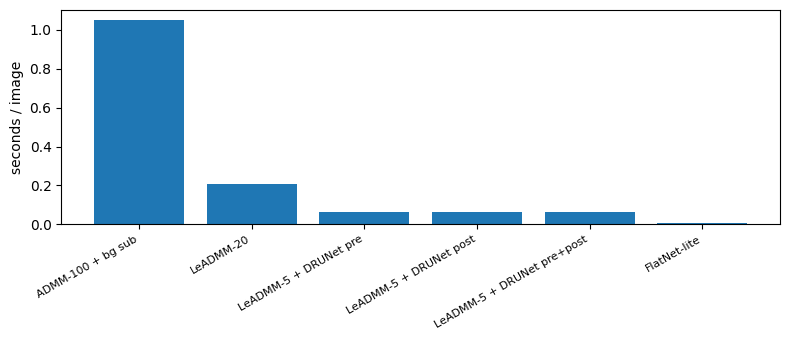

In [4]:
speed_path = TABLES / "speed.csv"
if speed_path.is_file():
    speed = pd.read_csv(speed_path)
else:
    speed = pd.DataFrame(json.loads((TABLES / "speed.json").read_text()))

display(
    speed[["method", "seconds_per_image", "images_per_second", "num_images", "device"]]
)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(speed["method"], speed["seconds_per_image"])
ax.set_ylabel("seconds / image")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), ha="right", fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

## 8. Training curves

Training curves live in comet report.

## 9. Reproduction

**Setup**

```bash
git clone https://github.com/tolyaho/lensless-computational-imaging
cd lensless-computational-imaging
pip install -r requirements.txt
python download_checkpoints.py --all
```

**Report assets**

```bash
python scripts/build_report_tables.py
python scripts/make_qualitative_grid.py --num-samples 5
python measure_speed.py --num-images 50 --warmup 5 --device cuda \
  --output-path reports/tables/speed.json
```

**Final models — config and checkpoint**

| Method | Config | Checkpoint |
| --- | --- | --- |
| ADMM-100 + bg sub | `inference` | none |
| LeADMM-20 | `inference_leadmm20` | `checkpoints/leadmm20.pth` |
| DRUNet pre | `inference_modular_pre` + `model=modular_leadmm5_pre_drunet8m` | `checkpoints/leadmm5_pre_drunet8m.pth` |
| DRUNet post | `inference_modular_post` + `model=modular_leadmm5_post_drunet8m` | `checkpoints/leadmm5_post_drunet8m.pth` |
| DRUNet pre+post | `inference_modular_prepost` + `model=modular_leadmm5_prepost_drunet8m` | `checkpoints/leadmm5_prepost_drunet8m.pth` |
| FlatNet-lite | `inference_flatnet` | `checkpoints/flatnet_lite.pth` |

**Best model example**

```bash
python inference.py -cn inference_modular_prepost \
  model=modular_leadmm5_prepost_drunet8m \
  checkpoint=checkpoints/leadmm5_prepost_drunet8m.pth \
  output_dir=outputs/final_leadmm5_drunet8m_prepost

python calculate_metrics.py \
  pred_dir=outputs/final_leadmm5_drunet8m_prepost/recon \
  gt_dir=outputs/final_leadmm5_drunet8m_prepost/lensed \
  output_path=outputs/final_leadmm5_drunet8m_prepost/metrics.json
```

Custom data: `notebooks/demo.ipynb`.

## What worked and what did not

**Worked**

- wave-propagation PSF from `lensless_helpers`
- 180-degree lensless rotation and aligned GT crop
- ROI metrics instead of full-frame PSNR
- background subtraction for fixed ADMM
- DRUNet post-processing
- pre+post architecture
- MSE + 0.1 LPIPS
- FlatNet-lite as a fast bonus baseline

**Did not work / was weak**

- naive resized-mask PSF
- raw ADMM without background correction
- LeADMM-20 alone
- tiny residual CNN processors
- relying on full-frame PSNR
- expecting big gains from only learned `mu` / `tau`

## Major challenges

- PSF simulation was the first big issue
- lensless / lensed alignment was annoying
- full-frame metrics were misleading because of black borders
- ADMM was slow because of many iterations and CG solves
- unrolled solvers were expensive to train / backprop through
- CNN capacity mattered a lot
- demo / checkpoints / report reproducibility took extra engineering

## 11. Summary

| Topic | Outcome |
| --- | --- |
| Best model | LeADMM-5 + DRUNet pre+post — **17.31 dB** PSNR |
| Key finding | DRUNet post beats learned ADMM scalars; post-only ~0.6 dB below pre+post |
| Bonus (non-ADMM) | FlatNet-lite — **16.12 dB**, **~0.005 s/image** |
| Baseline fixes | waveprop PSF, bg subtraction, ROI metrics |
| Weak paths | bilinear PSF, LeADMM-20 only, full-frame PSNR |